In [13]:
"""
Draw 100 random elliptic curves with conductor < 100,000 from the Cremona
database and group them into orbits under:

    (a, b) ~ (a', b')  iff  ∃ λ ∈ Q*  s.t.  a = λ² a'  and  b = λ³ b'

i.e. same quadratic-twist family.  Note a³/b² = a'³/b'² (same j-invariant
up to a constant), so curves in the same orbit share j.

Short Weierstrass: y² = x³ + a·x + b
"""

import random
from collections import defaultdict
from sage.databases.cremona import CremonaDatabase

# ── helpers ──────────────────────────────────────────────────────────────────

def short_weierstrass_coeffs(E):
    """Return (a, b) in y² = x³ + a x + b as exact rationals."""
    Esw = E.short_weierstrass_model()
    return QQ(Esw.a4()), QQ(Esw.a6())


def rational_square_root(r):
    """
    If r ∈ Q>0 is a perfect square in Q, return (True, λ) with λ > 0.
    Otherwise return (False, None).
    """
    r = QQ(r)
    if r <= 0:
        return False, None
    n, d = r.numerator(), r.denominator()

    def isqrt_exact(m):
        s = m.isqrt()
        return s if s * s == m else None

    sn = isqrt_exact(n)
    sd = isqrt_exact(d)
    if sn is not None and sd is not None:
        return True, QQ(sn) / QQ(sd)
    return False, None


def same_orbit(a1, b1, a2, b2):
    """
    Return True iff ∃ λ ∈ Q* with  a1 = λ² a2  and  b1 = λ³ b2.

    Special cases:
      • j = 1728  (b = 0): both b's zero; check a1/a2 is a square in Q.
      • j = 0     (a = 0): both a's zero; check b1/b2 is a cube in Q.
      • One zero, one non-zero in a slot → different j, not same orbit.
    """
    # --- j = 1728 family (b = 0) ---
    if b1 == 0 and b2 == 0:
        ok, _ = rational_square_root(a1 / a2)
        return ok

    # --- j = 0 family (a = 0) ---
    if a1 == 0 and a2 == 0:
        ratio = QQ(b1 / b2)
        if ratio <= 0:
            return False
        # check ratio is a perfect cube in Q
        n, d = ratio.numerator(), ratio.denominator()
        def is_cube(m):
            return all(e % 3 == 0 for _, e in factor(m)) if m > 1 else True
        return is_cube(n) and is_cube(d)

    # --- mixed zeros → different j-invariants ---
    if (a1 == 0) != (a2 == 0) or (b1 == 0) != (b2 == 0):
        return False

    # --- generic case ---
    ratio_a = QQ(a1) / QQ(a2)
    if ratio_a <= 0:
        return False   # λ² must be positive
    ok, lam = rational_square_root(ratio_a)
    if not ok:
        return False
    # Check b1/b2 == λ³  (λ could also be -λ, but λ³ sign must match)
    # Try both +λ and -λ
    return QQ(b1) / QQ(b2) in (lam**3, (-lam)**3)


# ── sample 100 curves ────────────────────────────────────────────────────────

print("Loading Cremona database …")
C = CremonaDatabase()

random.seed(int(42))

TARGET = 100

# Load pre-built list of rank-0 isogeny class labels (e.g. '11a', '37b', …)
print("Loading rank-0 isogeny class database …")
isos = load('Curve Database (Conductor < 100 000)/rank0_c1_to_100000_isogeny_classes.sobj')
print(f"Found {len(isos)} isogeny classes. Sampling {TARGET} …\n")

# Pick one curve per sampled isogeny class (the first curve, label + '1')
chosen  = random.sample(list(isos), TARGET)
sampled = []   # list of (cremona_label, a, b)
for iso_label in chosen:
    label = iso_label + '1'   # e.g. '11a' -> '11a1'
    try:
        E    = EllipticCurve(label)
        a, b = short_weierstrass_coeffs(E)
        sampled.append((label, a, b))
    except Exception:
        continue

print(f"Collected {len(sampled)} curves.\n")

# ── union-find ────────────────────────────────────────────────────────────────

parent = list(range(len(sampled)))

def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[ri] = rj

for i in range(len(sampled)):
    for j in range(i + 1, len(sampled)):
        _, a1, b1 = sampled[i]
        _, a2, b2 = sampled[j]
        if same_orbit(a1, b1, a2, b2):
            union(i, j)

# ── collect & report ──────────────────────────────────────────────────────────

orbits = defaultdict(list)
for i, (label, a, b) in enumerate(sampled):
    orbits[find(i)].append((label, a, b))

orbit_list  = sorted(orbits.values(), key=lambda o: -len(o))
num_orbits  = len(orbit_list)
singletons  = sum(1 for o in orbit_list if len(o) == 1)
non_trivial = [o for o in orbit_list if len(o) > 1]

print("=" * 60)
print(f"  Total curves sampled : {len(sampled)}")
print(f"  Distinct twist orbits: {num_orbits}")
print(f"  Singleton orbits     : {singletons}")
print(f"  Non-trivial orbits   : {len(non_trivial)}")
print("=" * 60)

if non_trivial:
    print("\nNon-trivial twist orbits:")
    for k, orbit in enumerate(non_trivial, 1):
        print(f"\n  Orbit {k}  (size {len(orbit)}):")
        for label, a, b in orbit:
            j = EllipticCurve([a, b]).j_invariant()
            print(f"    {label:20s}  a = {a},  b = {b},  j = {j}")
else:
    print("\nAll 100 curves lie in distinct twist orbits in this sample.")

print("\nOrbit size distribution:")
size_count = defaultdict(int)
for o in orbit_list:
    size_count[len(o)] += 1
for sz in sorted(size_count):
    print(f"  size {sz}: {size_count[sz]} orbit(s)  [{size_count[sz]*sz} curves]")

Loading Cremona database …
Loading rank-0 isogeny class database …
Found 168760 isogeny classes. Sampling 100 …

Collected 100 curves.

  Total curves sampled : 100
  Distinct twist orbits: 100
  Singleton orbits     : 100
  Non-trivial orbits   : 0

All 100 curves lie in distinct twist orbits in this sample.

Orbit size distribution:
  size 1: 100 orbit(s)  [100 curves]


In [1]:
from tqdm import tqdm

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100000)/curve_database_N1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# Build subdatabase of fixed curves
print('Building rank-restricted databases...')

rk0_curves = {}
rk1_curves = {}
rk2_curves = {}
rk3_curves = {}
for iso in tqdm(list(curve_db.keys()), 'Building databases'):
    rk = curve_db[iso]['rank']
    if rk == 0:
        rk0_curves[iso] = curve_db[iso]
    elif rk == 1:
        rk1_curves[iso] = curve_db[iso]
    elif rk == 2:
        rk2_curves[iso] = curve_db[iso]
    elif rk == 3:
        rk3_curves[iso] = curve_db[iso]

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes
Building rank-restricted databases...


Building databases: 100%|███████████████████████████████████████████████████| 437226/437226 [00:00<00:00, 758636.15it/s]


In [5]:
Nmin = 5000
Nmax = 10000
nsample_rk0 = 531
nsample_rk1 = 560

# ── Filter both ranks by conductor ──
Nisos_rk0, Ncurves_rk0 = [], {}
for iso in tqdm(list(rk0_curves.keys()), 'Conductor range (rank 0)'):
    N = rk0_curves[iso]['conductor']
    if Nmin <= N <= Nmax:
        Nisos_rk0.append(iso)
        Ncurves_rk0[iso] = rk0_curves[iso]

Nisos_rk1, Ncurves_rk1 = [], {}
for iso in tqdm(list(rk1_curves.keys()), 'Conductor range (rank 1)'):
    N = rk1_curves[iso]['conductor']
    if Nmin <= N <= Nmax:
        Nisos_rk1.append(iso)
        Ncurves_rk1[iso] = rk1_curves[iso]

# ── Build running averages separately ──
from random import shuffle
import numpy as np

shuffled_rk0 = Nisos_rk0[:]
shuffle(shuffled_rk0)
aps_rk0 = np.mean([Ncurves_rk0[iso]['ap_list'] for iso in shuffled_rk0[:nsample_rk0]], axis=0)

shuffled_rk1 = Nisos_rk1[:]
shuffle(shuffled_rk1)
aps_rk1 = np.mean([Ncurves_rk1[iso]['ap_list'] for iso in shuffled_rk1[:nsample_rk1]], axis=0)

Conductor range (rank 1): 100%|████████████████████████████████████████████| 222439/222439 [00:00<00:00, 1020400.63it/s]


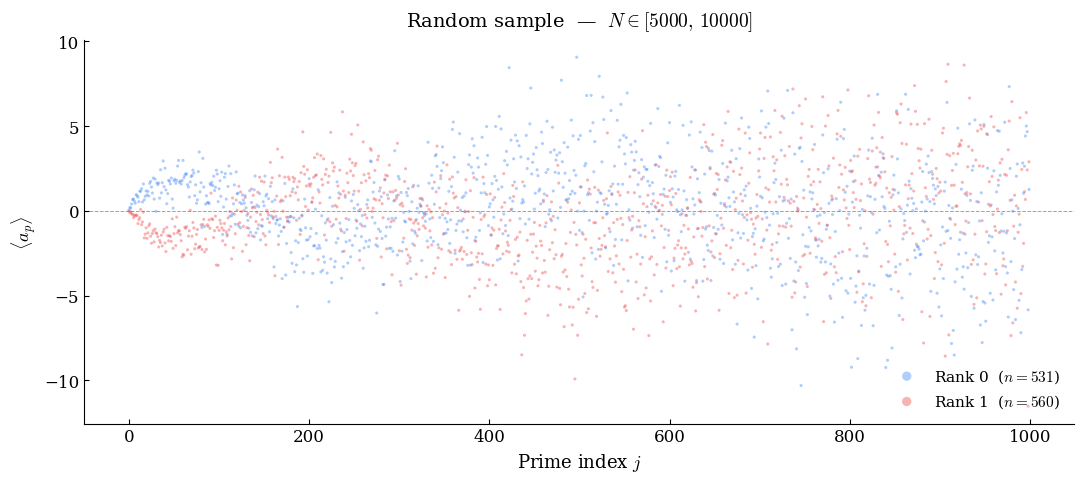

Saved to Random_curves/random_avg_aps_N5000_10000_n531_560.png


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import builtins
float, int = builtins.float, builtins.int

output_dir = 'Random_curves'
os.makedirs(output_dir, exist_ok=True)

# ── setup ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 12,
    'axes.linewidth': float(0.8),
    'figure.facecolor': 'white',
})

n_primes = len(aps_rk0)
idx = np.arange(n_primes, dtype=float)

# ── figure ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(idx, aps_rk0, s=int(5), alpha=float(0.4),
           color='#3b82f6', edgecolors='none', label=f'Rank 0  ($n = {len(shuffled_rk0[:nsample_rk0])}$)', zorder=2)
ax.scatter(idx, aps_rk1, s=int(5), alpha=float(0.4),
           color='#ef4444', edgecolors='none', label=f'Rank 1  ($n = {len(shuffled_rk1[:nsample_rk1])}$)', zorder=2)

ax.axhline(0, color='#94a3b8', lw=float(0.7), ls='--', zorder=1)

ax.set_xlabel('Prime index $j$', fontsize=int(13))
ax.set_ylabel(r'$\langle a_p \rangle$', fontsize=int(13))
ax.set_title(
    f'Random sample  —  $N \\in [{Nmin},\\, {Nmax}]$',
    fontsize=int(14), pad=int(10)
)
ax.legend(frameon=False, fontsize=int(11), markerscale=int(3), loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='in')

fig.tight_layout()

tag = f'N{Nmin}_{Nmax}_n{nsample_rk0}_{nsample_rk1}'
plot_path = f'{output_dir}/random_avg_aps_{tag}.png'
plt.savefig(plot_path, bbox_inches='tight', dpi=int(250))
plt.show()
print(f"Saved to {plot_path}")